Average temperature: 22.6°C
Files saved in 'data' folder


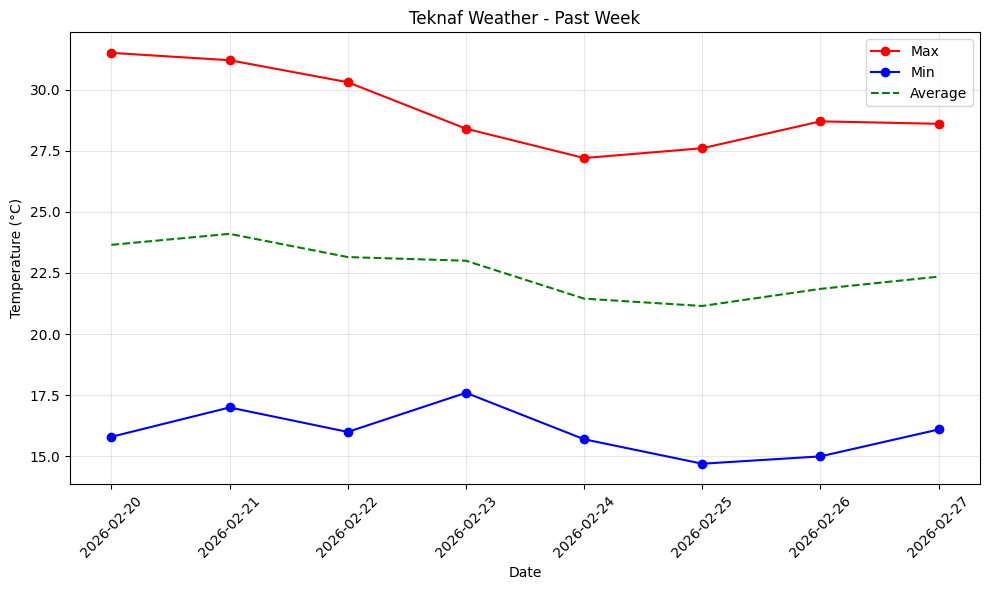

In [4]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import os

# 1. Get weather data
today = datetime.now()
week_ago = today - timedelta(days=7)
start_date = week_ago.strftime("%Y-%m-%d")
end_date = today.strftime("%Y-%m-%d")

url = f"https://api.open-meteo.com/v1/forecast?latitude=20.8625&longitude=2.35&start_date={start_date}&end_date={end_date}&daily=temperature_2m_max,temperature_2m_min"
response = requests.get(url)
data = response.json()

# 2. Process with pandas
df = pd.DataFrame({
    'date': pd.to_datetime(data['daily']['time']),
    'max_temp': data['daily']['temperature_2m_max'],
    'min_temp': data['daily']['temperature_2m_min']
})

# 3. Calculate average
df['avg_temp'] = (df['max_temp'] + df['min_temp']) / 2

# 4. Create visualization
plt.figure(figsize=(10, 6))
plt.plot(df['date'], df['max_temp'], 'r-o', label='Max')
plt.plot(df['date'], df['min_temp'], 'b-o', label='Min')
plt.plot(df['date'], df['avg_temp'], 'g--', label='Average')

plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Teknaf Weather - Past Week')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

# 5. Save everything
if not os.path.exists('data'):
    os.makedirs('data')

plt.savefig('data/weather_chart.png')
df.to_csv('data/paris_weather.csv', index=False)

print(f"Average temperature: {df['avg_temp'].mean():.1f}°C")
print("Files saved in 'data' folder")